In [1]:
from sympy import Function, Symbol, symbols, simplify, Eq, Symbol, latex, pprint, collect, expand
from sympy import init_printing
from IPython.display import display, Math

init_printing(use_latex=True)

In [2]:
import re
from IPython.display import display, Math

def color_terms(latex_str):
    latex_str = re.sub(
        r'(\\phi_\{REF\}\{\\left\(.+?\\right\)\})',
        r'{\\color{purple} \1}',
        latex_str
    )
    # Color all q_i(t) terms orange
    latex_str = re.sub(
        r'(q_\{([1])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{red} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(q_\{([2])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{orange} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(q_\{([3])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{yellow} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(\\epsilon_\{([A])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{Cyan} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(\\epsilon_\{([B])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{Aquamarine} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(\\epsilon_\{([C])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{SpringGreen} \1{\\left(\3\\right)}}',
        latex_str
    )
    return latex_str

In [3]:
# ── time variable ─────────────────────────────────────────────────────────────
t = Symbol('t')

# ── delay parameters ──────────────────────────────────────────────────────────
tau12, tau21, tau13, tau31, tau23, tau32 = symbols(
    r'\tau_{12} \tau_{21} \tau_{13} \tau_{31} \tau_{23} \tau_{32}',
    real=True, positive=True
)

# ── laser angular frequencies (physical + measurement offsets) ────────────────
omega1, omega2, omega3 = symbols(r'\omega_1 \omega_2 \omega_3', real=True)
omega1m, omega2m, omega3m = symbols(r'\omega_1^m \omega_2^m \omega_3^m', real=True)

For now, we assume frequencies to be constant in time. Hartwig et. al. did a bit of analysis how this affects the clock noise removal.

In [4]:
# ── abstract time-dependent functions ─────────────────────────────────────────
phi1  = Function(r'\phi_1')   # laser phase noise, s/c 1
phi2  = Function(r'\phi_2')
phi3  = Function(r'\phi_3')
phiREF  = Function(r'\phi_{REF}')

epsilonA = Function(r'\epsilon_A')  # clock noise, s/c 1 (master)
epsilonB = Function(r'\epsilon_B')  # clock noise, s/c 2
epsilonC = Function(r'\epsilon_C')  # clock noise, s/c 3

omegaREFA, omegaREFB, omegaREFC = symbols(r'\omega^{REF}_A \omega^{REF}_B \omega^{REF}_C', real=True)

q1 = Function('q_1')
q2 = Function('q_2')
q3 = Function('q_3')


N1_1 = Function('N_{1_1}') # measured on board 1 coming from laser 1
N2_2 = Function('N_{2_2}')
N3_3 = Function('N_{3_3}')

N1_2 = Function('N_{1_2}')
N1_3 = Function('N_{1_3}')
N2_1 = Function('N_{2_1}')
N2_3 = Function('N_{2_3}')
N3_1 = Function('N_{3_1}')
N3_2 = Function('N_{3_2}')


n1_1 = Function('n_{1_1}') # measured on board 1 coming from laser 1
n2_2 = Function('n_{2_2}')
n3_3 = Function('n_{3_3}')

n1_2 = Function('n_{1_2}')
n1_3 = Function('n _{1_3}')
n2_1 = Function('n_{2_1}')
n2_3 = Function('n_{2_3}')
n3_1 = Function('n_{3_1}')
n3_2 = Function('n_{3_2}')


N1_m = Function('P_{1}^{m}')
N2_m = Function('P_{2}^{m}')
N3_m = Function('P_{3}^{m}')

In [5]:
def D(expr, tau):
    return expr.subs(t, t - tau)

For the clock jitters, $\epsilon$ variables are used for the delay line boards. The $q$ variables are for the Mokus and in reference to the global time.

In [6]:
# Map spacecraft index → (phi, q, omega, omega_m, clock_epsilon)
sc = {
    1: (phi1, q1, omega1, omega1m, epsilonA, omegaREFA, N1_m),
    2: (phi2, q2, omega2, omega2m, epsilonB, omegaREFB, N2_m),
    3: (phi3, q3, omega3, omega3m, epsilonC, omegaREFC, N3_m),
}

tau = {
    (1,2): tau12, (2,1): tau21,
    (1,3): tau13, (3,1): tau31,
    (2,3): tau23, (3,2): tau32,
}

N = {
    (1,2): (N1_1, N1_2, n1_1, n1_2), (1,3): (N1_1, N1_3, n1_1, n1_3),
    (2,1): (N2_1, N2_2, n2_1, n2_2), (2,3): (N2_2, N2_3, n2_2, n2_3),
    (3,1): (N3_1, N3_3, n3_1, n3_2), (3,2): (N3_3, N3_2, n3_3, n3_2)
}

eta    = {}
etaSB  = {}
REF  = {}
r = {}
r_m = {}

include_phi = True 
include_clock_noise = True
include_board_jitter = True   
include_REF_laser = False
include_optical_noise = False
include_modulation_noise = False  

for (i, j) in tau:
    phi_i, q_i, om_i, omm_i, eps_i, omegaREFi, N_i_m = sc[i]
    phi_j, q_j, om_j, omm_j, eps_j, omegaREFj, N_j_m = sc[j]
    t_ij = tau[(i, j)]
    Nij, Nji, nij, nji = N[(i,j)]

    phi_terms = (D(phi_j(t)-int(include_REF_laser)*phiREF(t), t_ij) - (phi_i(t)-int(include_REF_laser)*phiREF(t))) if include_phi else 0

    clock_terms_C = (- (om_j - om_i) * q_i(t)) if include_clock_noise else 0
    clock_terms_SB = (- (om_j - om_i + omm_j - omm_i) * q_i(t) - omm_i * q_i(t) + omm_j * D(q_j(t), t_ij)) if include_clock_noise else 0
    
    board_terms_c = (om_j * (eps_i(t) - D(eps_i(t), t_ij))) if include_board_jitter else 0
    board_terms_SB = ((om_j + omm_j) * (eps_i(t) - D(eps_i(t), t_ij))) if include_board_jitter else 0
    
    optical_terms = (Nij(t) - D(Nji(t), t_ij)) if include_optical_noise else 0
    optical_terms_SB = (nij(t) - D(nji(t), t_ij)) if include_optical_noise else 0

    eta[(i,j)] = (phi_terms + clock_terms_C + board_terms_c + optical_terms)

    etaSB[(i,j)] = collect(expand(phi_terms + clock_terms_SB + board_terms_SB + optical_terms_SB + int(include_modulation_noise) * (N_i_m(t) - D(N_j_m(t), t_ij))), [q_i(t), q_j(t)])

    r[(i,j)] = simplify(-(eta[(i,j)] - etaSB[(i,j)]) / omm_j)


    #phi_terms2 = (phi_j(t)-int(include_REF_laser)*phiREF(t) - (phi_i(t)-int(include_REF_laser)*phiREF(t))) if include_phi else 0
    #r_m[(i,j)] = collect(expand(phi_terms2), 
    #                     [q_i(t), q_j(t)])

    REF[(i,j)] = ( - int(include_clock_noise)*q_j(t) + int(include_board_jitter) * eps_i(t) ) # REF measured by the other PM, missing omegaREFi  *

The $\epsilon(t)$ terms originate from clock noise on the delay line boards which we will use three of. So we have A, B and C. Each corresponds to one spacecraft so the board A is where we apply delays 2 $\rightarrow$ 1 and 3 $\rightarrow$ 1. The $q(t)$ terms come from the Mokus. These are LISA-like, as in LISA will see similat clock noise coupling from the PM. All clock terms are given w.r.t the global clock, which we won't really ever know.

In [7]:
if True:
    for (i, j) in tau:
        display(Math(r'\eta_{' + str(i) + str(j) + '} = ' + color_terms(latex(eta[(i,j)]))))
        display(Math(r'\eta_{' + str(i) + str(j) + '}^{SB} = ' + color_terms(latex(etaSB[(i,j)]))))
        display(Math(r'\frac{r_{' + str(i) + str(j) + r'}}{\omega_{' + str(j) + '}^m} = ' + color_terms(latex(r[(i,j)]))))
        display(Math(r'\frac{REF_{' + str(i) + str(j) + r'}}{ \omega_{' + str(j) + '}^m} = ' + color_terms(latex(REF[(i,j)]))))
        #display(Math(r'\frac{r^{\text{m}}_{' + str(i) + str(j) + r'}}{\omega_{' + str(j) + '}^m} = ' + color_terms(latex(r_m[(i,j)]))))
        print("------------------------------------------------------")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------------------------------


...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------------------------------


We actually look at first generation TDI here. I do not know how to properly cancel out the timechaning delays with symbolic calculations.

In [8]:
def P12(expr): return expr - D(expr, tau13 + tau31)
def P21(expr): return D(expr, tau12) - D(expr, tau12 + tau13 + tau31)
def P13(expr): return -(expr - D(expr, tau12 + tau21))
def P31(expr): return -(D(expr, tau13) - D(expr, tau13 + tau12 + tau21))

# X1
X1 = collect(expand(P13(eta[(1,3)] + D(eta[(3,1)], tau13))+ P12(eta[(1,2)] + D(eta[(2,1)], tau12))), [q1(t), q2(t), q3(t), epsilonA(t), epsilonB(t), epsilonC(t)])

In [9]:
display(Math(r'X_1 = ' + color_terms(latex(X1)))) 

<IPython.core.display.Math object>

In [10]:
R = {}

R[(1,2)] = -(r[(1,3)] + D(r[(3,1)], tau13))

R[(1,3)] = r[(1,2)] + D(r[(2,1)], tau12)

R[(2,1)] = (r[(1,2)]
             - r[(1,3)]
             - D(r[(3,1)], tau13)
             - D(r[(1,2)], tau13 + tau31))

R[(3,1)] = (-r[(1,3)]
              + r[(1,2)]
              + D(r[(2,1)], tau12)
              + D(r[(1,3)], tau12 + tau21))

R[(2,3)] = 0
R[(3,2)] = 0

In [11]:
a = {
    (1,2): omega1 - omega2,
    (2,1): omega2 - omega1,
    (1,3): omega1 - omega3,
    (3,1): omega3 - omega1,
    (2,3): omega2 - omega3,
    (3,2): omega3 - omega2,
}

# clockwise triplets I+_3
triplets = [(1,2,3), (2,3,1), (3,1,2)]

correction = 0
for (i, j, k) in triplets:
    correction -= (
        - a[(i,j)] * R[(i,j)]
        - a[(i,k)] * R[(i,k)]
    )

X1c = simplify(X1 - correction) # Added a minus here bc the original r calc was flipped, which i now fixed, but didnt change in the correcting variables

In [12]:
print("The X1 expression is:")
display(Math(r'X_1 = ' + color_terms(latex(X1))))
#print("The clock-jitter correction term is:")
#display(Math(r'X_1 = ' + color_terms(latex(simplify(-correction)))))
print("The corrected X1 expression is:")
display(Math(r'X_1 = ' + color_terms(latex(X1c))))

The X1 expression is:


<IPython.core.display.Math object>

The corrected X1 expression is:


<IPython.core.display.Math object>

In [13]:
REF_AB= REF[(1,3)] - REF[(2,3)]
REF_AC= REF[(3,2)] - REF[(1,2)]
REF_CB= REF[(2,1)] - REF[(3,1)]

display(Math(r'REF_{AB} = ' + color_terms(latex(REF_AB))))
display(Math(r'REF_{AC} = ' + color_terms(latex(REF_AC))))
display(Math(r'REF_{CB} = ' + color_terms(latex(REF_CB))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:
Corr1 = omega1*(D(REF_AB, tau12) - D(REF_AB, tau12 + tau21) - D(REF_AB, tau12 + tau13 + tau31))
Corr2 = omega1*(D(REF_AC, tau13) - D(REF_AC, tau13 + tau31) - D(REF_AC, tau12 + tau13 + tau21))
Corr3 = -omega1*(D(REF_CB, tau12 + tau13 + tau21 + tau31))
display(Math(r'X_1 = ' + color_terms(latex(simplify(X1c + Corr1 + Corr2 + Corr3)))))

<IPython.core.display.Math object>

Lets move it to frequency domain?

In [24]:
import numpy as np

In [54]:
from sympy import exp, I, expand, Symbol, lambdify
from sympy import Function as SympyFunction
import numpy as np

omega_sym = Symbol('omega', real=True, positive=True)

# Master list of ALL noise Function classes that can appear in any expression.
# Used by get_transfer_function to zero out everything except the target noise.
master_noise_funcs = [
    phi1, phi2, phi3,
    q1, q2, q3,
    epsilonA, epsilonB, epsilonC,
    N1_m, N2_m, N3_m,
    N1_1, N1_2, N1_3, N2_1, N2_2, N2_3, N3_1, N3_2, N3_3,
    n1_1, n1_2, n2_1, n2_2, n3_1, n3_2, n3_3,
]

def build_eta_for_noise(noise_type):
    eta = {}
    for (i, j) in tau:
        phi_i, q_i, om_i, omm_i, eps_i, _, N_i_m = sc[i]
        phi_j, q_j, om_j, omm_j, eps_j, _, N_j_m = sc[j]
        t_ij = tau[(i, j)]
        Nij, Nji, nij, nji = N[(i, j)]
        if noise_type == 'phi':
            eta[(i,j)] = expand(D(phi_j(t), t_ij) - phi_i(t))
        elif noise_type == 'clock':
            eta[(i,j)] = expand(-(om_j - om_i) * q_i(t))
        elif noise_type == 'board':
            eta[(i,j)] = expand(om_j * (eps_i(t) - D(eps_i(t), t_ij)))
        elif noise_type == 'optical':
            eta[(i,j)] = expand(Nij(t) - D(Nji(t), t_ij))
        elif noise_type == 'modulation':
            eta[(i,j)] = expand(N_i_m(t) - D(N_j_m(t), t_ij))
        else:
            eta[(i,j)] = 0
    return eta

def build_tdi_from_eta(eta, tdi_name='X1'):
    if tdi_name == 'X1':
        def P12(e): return e - D(e, tau13 + tau31)
        def P13(e): return -(e - D(e, tau12 + tau21))
        return expand(P13(eta[(1,3)] + D(eta[(3,1)], tau13)) + P12(eta[(1,2)] + D(eta[(2,1)], tau12)))
    elif tdi_name == 'alpha1':
        return expand(eta[(1,2)] + D(eta[(2,3)], tau12) + D(eta[(3,1)], tau12 + tau23)
                    - eta[(1,3)] - D(eta[(3,2)], tau13) - D(eta[(2,1)], tau13 + tau32))
    else:
        raise ValueError(f"Unknown TDI '{tdi_name}'")

def get_transfer_function(tdi_expr, noise_func):
    """Extract H(omega) for noise_func. Zeros out ALL other noise functions
    in master_noise_funcs so stray terms (e.g. epsilon in X1c) don't survive."""
    zero_subs = {}
    for fn in master_noise_funcs:
        if fn == noise_func:
            continue
        for inst in tdi_expr.atoms(SympyFunction):
            if inst.func == fn:
                zero_subs[inst] = 0
    expr2 = tdi_expr.subs(zero_subs)
    phase_subs = {inst: exp(-I * omega_sym * (t - inst.args[0]))
                  for inst in expr2.atoms(SympyFunction) if inst.func == noise_func}
    return expand(expr2.subs(phase_subs))

def _eval_H(H_num, omegas):
    """lambdify returns a scalar when H is constant; broadcast to array."""
    return np.ones(len(omegas), dtype=complex) * H_num(omegas)

print("Cell 1 ready.")


Cell 1 ready.


In [72]:
from sympy import collect, latex
from IPython.display import display, Math

noise_to_check = 'clock'   # change to 'optical', 'clock', 'modulation', 'phi'
fn_list_map = {
    'optical':    [N1_1,N1_2,N1_3,N2_1,N2_2,N2_3,N3_1,N3_2,N3_3],
    'modulation': [N1_m, N2_m, N3_m],
    'clock':      [q1, q2, q3],
    'board':      [epsilonA, epsilonB, epsilonC],
    'phi':        [phi1, phi2, phi3],
}

eta_k  = build_eta_for_noise(noise_to_check)
X1_k   = build_tdi_from_eta(eta_k, 'X1')

print(f"Noise type: {noise_to_check}")
print(f"TDI combination: X1")
print()

for fn in fn_list_map[noise_to_check]:
    H = get_transfer_function(X1_k, fn)
    display(Math(f'H_{{\\mathrm{{{fn.name}}}}}(\\omega) = ' + latex(H)))


Noise type: clock
TDI combination: X1



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

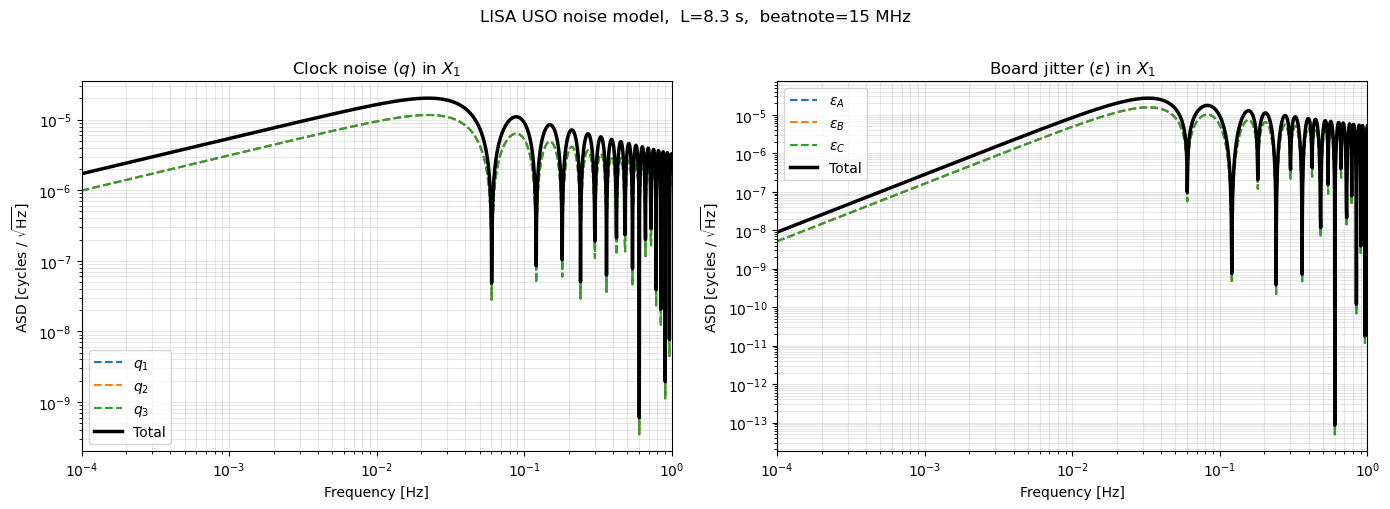

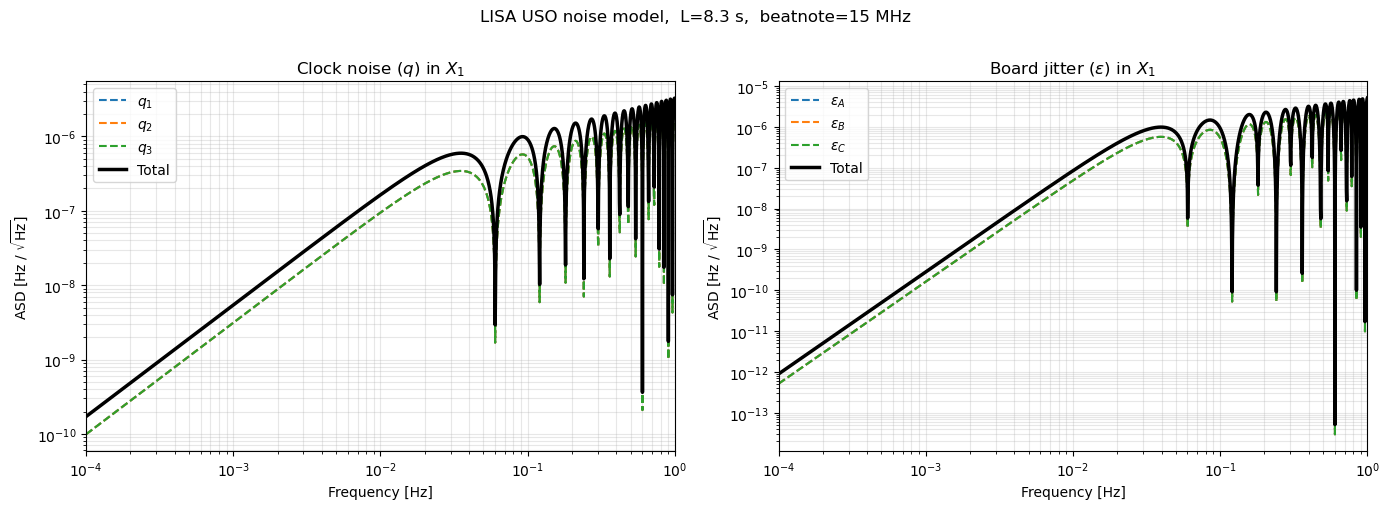

Done.


In [88]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
L     = 8.3
freqs = np.logspace(-4, 0, 2000)
w     = 2 * np.pi * freqs

t12 = t21 = t13 = t31 = t23 = t32 = L

def ph(tau):
    return np.exp(-1j * w * tau)


f_beat_12 = 15e6     # Hz — beatnote SC1-SC2  (omega_2 - omega_1) / 2pi
f_beat_13 = 15e6     # Hz — beatnote SC1-SC3  (omega_1 - omega_3) / 2pi  (sign absorbed below)
f_beat_23 = 15e6     # Hz — beatnote SC2-SC3  (omega_3 - omega_2) / 2pi

beat_12 = 2 * np.pi * f_beat_12
beat_13 = 2 * np.pi * f_beat_13
beat_23 = 2 * np.pi * f_beat_23

# Board jitter: epsilon_i is a timing error on the delay board for spacecraft i.
# It couples through the frequency of the signal being delayed on that board.
# Set this to the RF/optical frequency of your actual signal.
f_signal = 15e6      # Hz — frequency of signal on delay board
omega_sig = 2 * np.pi * f_signal

# ── Clock noise transfer functions ───────────────────────────────────────────
# Simplified forms (equal arms):
#   H_q1 = beat_23 * (1 - ph(2L))
#   H_q2 = beat_12 * ph(L) * (1 - ph(2L))       [note: omega_2-omega_1 = +beat_12]
#   H_q3 = -beat_13 * ph(L) * (1 - ph(2L))      [note: omega_1-omega_3 = +beat_13]
# But we keep the full expressions for generality (unequal arms possible):

H_q1 = ( beat_23 * (1 - ph(t13)*ph(t31)) )   # (o3-o2)*(1 - ph(2L))

H_q2 = ( beat_12 * ph(t12) * (1 - ph(t13)*ph(t31)) )

H_q3 = ( -beat_13 * ph(t13) * (1 - ph(t12)*ph(t21)) )

# ── Board jitter transfer functions ──────────────────────────────────────────
# H_A = (o2-o3)*[1 - ph(2L) - ph(L) + ph(3L)]  -- but o2-o3 = -beat_23
# H_B = omega_sig * ph(L) * [1 - ph(L) - ph(2L) + ph(3L)]
# H_C = -omega_sig * ph(L) * [1 - ph(L) - ph(2L) + ph(3L)]
# H_A ~ beat_23 (tiny compared to H_B/C if beat_23 << omega_sig)

H_A = (  (- beat_23)   # o2 - o3
       * (1 - ph(t13)*ph(t31) - ph(t12) + ph(t12)*ph(t13)*ph(t31)) )

H_B = ( omega_sig * ph(t12)
       * (1 - ph(t21) - ph(t13)*ph(t31) + ph(t13)*ph(t21)*ph(t31)) )

H_C = ( -omega_sig * ph(t13)
       * (1 - ph(t31) - ph(t12)*ph(t21) + ph(t12)*ph(t13)*ph(t21)) )

# ── LISA USO noise: S = 4e-27 / f  [frac freq^2/Hz] ─────────────────────────
S_uso = 4e-27 / freqs

# Output in cycles^2/Hz: |H [rad/s]|^2 * S [frac^2/Hz] / (2pi)^2
S_q1 = np.abs(H_q1)**2 * S_uso / (2*np.pi)**2
S_q2 = np.abs(H_q2)**2 * S_uso / (2*np.pi)**2
S_q3 = np.abs(H_q3)**2 * S_uso / (2*np.pi)**2

S_A  = np.abs(H_A)**2  * S_uso / (2*np.pi)**2
S_B  = np.abs(H_B)**2  * S_uso / (2*np.pi)**2
S_C  = np.abs(H_C)**2  * S_uso / (2*np.pi)**2

S_clock_total = S_q1 + S_q2 + S_q3
S_board_total = S_A  + S_B  + S_C

# Convert cycles/rtHz -> Hz/rtHz: multiply ASD by f  (freq = cycles/s)
def to_hz(S_cycles):
    return np.sqrt(S_cycles) * freqs

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clock noise
ax = axes[0]
ax.loglog(freqs, np.sqrt(S_q1),         lw=1.5, ls='--', label=r'$q_1$')
ax.loglog(freqs, np.sqrt(S_q2),         lw=1.5, ls='--', label=r'$q_2$')
ax.loglog(freqs, np.sqrt(S_q3),         lw=1.5, ls='--', label=r'$q_3$')
ax.loglog(freqs, np.sqrt(S_clock_total),lw=2.5, color='k', label='Total')
ax.set_title(r'Clock noise ($q$) in $X_1$')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [cycles / $\sqrt{\mathrm{Hz}}$]')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([freqs[0], freqs[-1]])

# Board jitter
ax = axes[1]
ax.loglog(freqs, np.sqrt(S_A),          lw=1.5, ls='--', label=r'$\epsilon_A$')
ax.loglog(freqs, np.sqrt(S_B),          lw=1.5, ls='--', label=r'$\epsilon_B$')
ax.loglog(freqs, np.sqrt(S_C),          lw=1.5, ls='--', label=r'$\epsilon_C$')
ax.loglog(freqs, np.sqrt(S_board_total),lw=2.5, color='k', label='Total')
ax.set_title(r'Board jitter ($\epsilon$) in $X_1$')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [cycles / $\sqrt{\mathrm{Hz}}$]')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([freqs[0], freqs[-1]])

plt.suptitle(f'LISA USO noise model,  L={L} s,  beatnote={f_beat_12/1e6:.0f} MHz', y=1.01)
plt.tight_layout()

# ── Same in Hz/rtHz ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.loglog(freqs, to_hz(S_q1),          lw=1.5, ls='--', label=r'$q_1$')
ax.loglog(freqs, to_hz(S_q2),          lw=1.5, ls='--', label=r'$q_2$')
ax.loglog(freqs, to_hz(S_q3),          lw=1.5, ls='--', label=r'$q_3$')
ax.loglog(freqs, to_hz(S_clock_total), lw=2.5, color='k', label='Total')
ax.set_title(r'Clock noise ($q$) in $X_1$')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [Hz / $\sqrt{\mathrm{Hz}}$]')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([freqs[0], freqs[-1]])

ax = axes[1]
ax.loglog(freqs, to_hz(S_A),           lw=1.5, ls='--', label=r'$\epsilon_A$')
ax.loglog(freqs, to_hz(S_B),           lw=1.5, ls='--', label=r'$\epsilon_B$')
ax.loglog(freqs, to_hz(S_C),           lw=1.5, ls='--', label=r'$\epsilon_C$')
ax.loglog(freqs, to_hz(S_board_total), lw=2.5, color='k', label='Total')
ax.set_title(r'Board jitter ($\epsilon$) in $X_1$')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [Hz / $\sqrt{\mathrm{Hz}}$]')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([freqs[0], freqs[-1]])

plt.suptitle(f'LISA USO noise model,  L={L} s,  beatnote={f_beat_12/1e6:.0f} MHz', y=1.01)
plt.tight_layout()

plt.show()
print("Done.")

Let's try with Sagnac

In [65]:
# Sagnac alpha_1 centered on SC1
# alpha_1 = eta12 + D12*eta23 + D123*eta31 - eta13 - D13*eta32 - D132*eta21

def P12_sagnac(expr): return expr
def P23_sagnac(expr): return D(expr, tau12)
def P31_sagnac(expr): return D(expr, tau12 + tau23)
def P13_sagnac(expr): return -expr
def P32_sagnac(expr): return -D(expr, tau13)
def P21_sagnac(expr): return -D(expr, tau13 + tau32)

R_sagnac = {}
R_sagnac[(1,2)] = 0
R_sagnac[(2,3)] = r[(1,2)]
R_sagnac[(3,1)] = r[(1,2)] + D(r[(2,3)], tau12)
R_sagnac[(1,3)] = 0
R_sagnac[(3,2)] = -r[(1,3)]
R_sagnac[(2,1)] = -(r[(1,3)] + D(r[(3,2)], tau13))

In [40]:
a = {
    (1,2): omega1 - omega2,
    (2,1): omega2 - omega1,
    (1,3): omega1 - omega3,
    (3,1): omega3 - omega1,
    (2,3): omega2 - omega3,
    (3,2): omega3 - omega2,
}

# clockwise triplets I+_3
triplets = [(1,2,3), (2,3,1), (3,1,2)]

correction = 0
for (i, j, k) in triplets:
    correction -= (
        - a[(i,j)] * R_sagnac[(i,j)]
        - a[(i,k)] * R_sagnac[(i,k)]
    )

alpha1 = collect(expand(
      P12_sagnac(eta[(1,2)])
    + P23_sagnac(eta[(2,3)])
    + P31_sagnac(eta[(3,1)])
    + P13_sagnac(eta[(1,3)])
    + P32_sagnac(eta[(3,2)])
    + P21_sagnac(eta[(2,1)])
), [q1(t), q2(t), q3(t), epsilonA(t), epsilonB(t), epsilonC(t)])


alpha1c = simplify(alpha1 - correction)

print("The alpha_1 expression is:")
display(Math(r'\alpha_1 = ' + color_terms(latex(alpha1))))  
print("The corrected alpha_1 expression is:")
display(Math(r'\alpha_1 = ' + color_terms(latex(alpha1c))))

The alpha_1 expression is:


<IPython.core.display.Math object>

The corrected alpha_1 expression is:


<IPython.core.display.Math object>

In [ ]:
display(latex(alpha1))

'\\phi_{1}{\\left(- \\tau_{12} - \\tau_{23} - \\tau_{31} + t \\right)} - \\phi_{1}{\\left(- \\tau_{13} - \\tau_{21} - \\tau_{32} + t \\right)}'

In [ ]:
CorrA_sagnac = omega1 * (D(REF_AC, tau13) + D(REF_AB, tau12))
CorrBC_sagnac = omega1 * (D(REF_CB, tau12+tau23) + D(REF_CB, tau13+tau32) - D(REF_CB, tau12 + tau23 + tau31))

alpha1_corrected = simplify(alpha1c + CorrA_sagnac + CorrBC_sagnac).subs({tau12:tau21, tau13: tau31, tau23: tau32})
print("The alpha_1 expression with only REF corrections is:")
display(Math(r'\alpha_1 = ' + color_terms(latex(alpha1_corrected))))

The alpha_1 expression with only REF corrections is:


<IPython.core.display.Math object>

Let's see if we can get rid of the board jitters before the TDI

cant